In [1]:
import pandas as pd
import numpy as np

In [273]:
gradient_data = pd.read_parquet(
    "../data/processed/gradient_data.parquet"
)

In [274]:
gradient_data.columns

Index(['timestamp', 'ws100', 'wd100', 'wd10', 'wind_shear',
       'relative_humidity', 'air_density', 'blh', 'tcc', 'tp', 'ssrd', 'i10fg',
       'WIND', 'wd100_sin', 'wd100_cos', 'wd10_sin', 'wd10_cos', 'hour',
       'day_of_week', 'month', 'day_of_year', 'hour_sin', 'hour_cos',
       'month_sin', 'month_cos', 'gen_lag_24', 'gen_lag_168',
       'ws100_roll_mean_6', 'ws100_roll_mean_24', 'ws100_roll_std_6',
       'ws100_roll_std_24', 'gen_lag_24_roll_mean_6',
       'gen_lag_24_roll_mean_24', 'gen_lag_24_roll_std_6',
       'gen_lag_24_roll_std_24'],
      dtype='object')

In [220]:
rnn_data = pd.read_parquet(
    "../data/processed/rnn_data.parquet"
)

<h1>XGBoost

Model built using just the atmospheric variables

In [275]:
X = gradient_data.drop(columns=["WIND", "timestamp"])
y = gradient_data["WIND"]

In [276]:
train_size = int(len(X) * 0.70)
val_size = int(len(X) * 0.15)

X_train = X.iloc[:train_size]
X_val = X.iloc[train_size:train_size + val_size]
X_test = X.iloc[train_size + val_size:]

y_train = y.iloc[:train_size]
y_val = y.iloc[train_size:train_size + val_size]
y_test = y.iloc[train_size + val_size:]

In [197]:
print(X_train.dtypes.unique())

[dtype('float64') dtype('int32')]


In [133]:
print(X.columns)

Index(['ws100', 'wd100', 'wd10', 'wind_shear', 'relative_humidity',
       'air_density', 'blh', 'tcc', 'tp', 'ssrd', 'i10fg', 'wd100_sin',
       'wd100_cos', 'wd10_sin', 'wd10_cos', 'hour', 'day_of_week', 'month',
       'day_of_year', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
       'ws100_roll_mean_6', 'ws100_roll_mean_24', 'ws100_roll_std_6',
       'ws100_roll_std_24'],
      dtype='object')


In [198]:
print("train", X_train.shape)
print("val", X_val.shape)
print("test", X_test.shape)

train (48972, 33)
val (10494, 33)
test (10494, 33)


In [135]:
#hyper parameter tuning
from sklearn.model_selection import TimeSeriesSplit

In [136]:
tscv = TimeSeriesSplit(n_splits=5)

In [ ]:
#!pip install xgboost

<h1> basic model using only atmospheric variables


In [137]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [138]:
y_pred = xgb.predict(X_test)

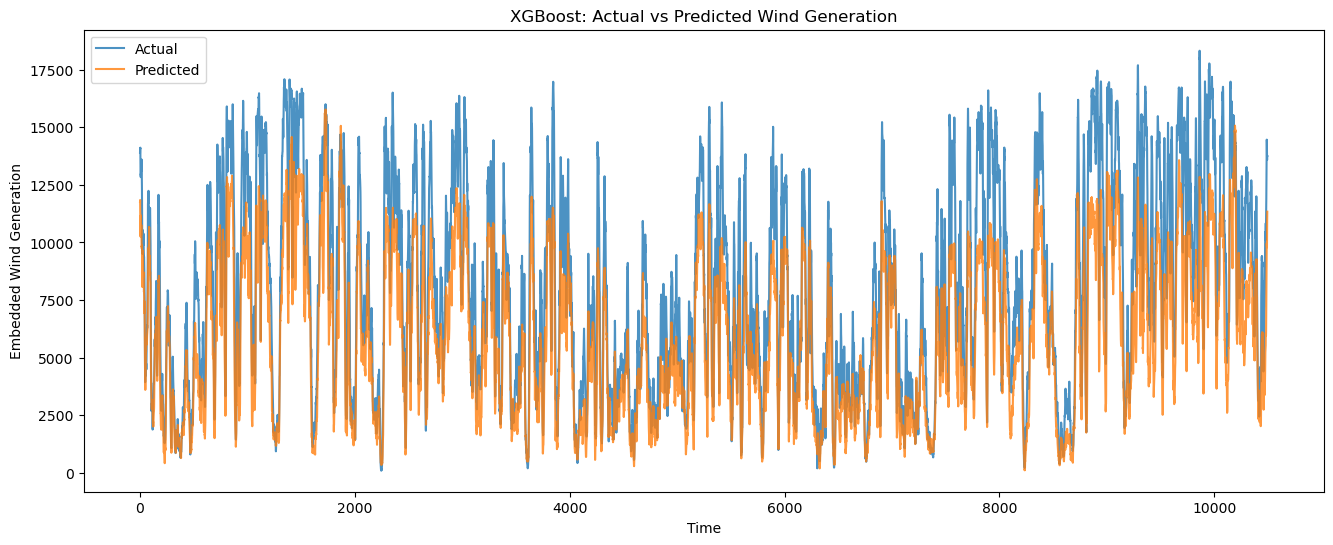

In [139]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))

plt.plot(
    y_test.values,
    label="Actual",
    alpha=0.8
)

plt.plot(
    y_pred,
    label="Predicted",
    alpha=0.8
)

plt.title("XGBoost: Actual vs Predicted Wind Generation")
plt.xlabel("Time")
plt.ylabel("Embedded Wind Generation")
plt.legend()
plt.show()

In [140]:
results = pd.DataFrame({
    'Timestamp': gradient_data.loc[y_test.index, 'timestamp'],
    "Actual": y_test,
    "Predicted": y_pred
})

results["Error"] = results["Actual"] - results["Predicted"]
results["Absolute_Error"] = results["Error"].abs()

xg_results = results.copy()

In [ ]:
xg_results.to_csv(
    "../data/results/xg_results.csv",
    index=False
)

In [142]:
xg_results

,Timestamp,Actual,Predicted,Error,Absolute_Error
59466,2024-10-20 18:00:00,13901.5,11762.466797,2139.033203,2139.033203
59467,2024-10-20 19:00:00,14090.0,11842.032227,2247.967773,2247.967773
59468,2024-10-20 20:00:00,14069.5,11176.354492,2893.145508,2893.145508
59469,2024-10-20 21:00:00,14113.5,10853.151367,3260.348633,3260.348633
59470,2024-10-20 22:00:00,13417.5,10312.522461,3104.977539,3104.977539
...,...,...,...,...,...
69955,2025-12-31 19:00:00,14324.0,9832.641602,4491.358398,4491.358398
69956,2025-12-31 20:00:00,13765.0,9790.073242,3974.926758,3974.926758
69957,2025-12-31 21:00:00,13578.5,10588.630859,2989.869141,2989.869141
69958,2025-12-31 22:00:00,13776.0,10990.905273,2785.094727,2785.094727


<h2> evaluation matrics

In [143]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y_val_pred = xgb.predict(X_val)

mae = mean_absolute_error(y_val, y_val_pred)

mse = mean_squared_error(y_val, y_val_pred)
rmse= np.sqrt(mse)

r2 = r2_score(y_val, y_val_pred)

print(f"MAE: {mae: .4f}")
print(f"RMSE: {rmse: .4f}")
print(f"R2: {r2: .4f}")

MAE:  1476.2179
RMSE:  1882.6508
R2:  0.7964


<h3>feature importance

In [144]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
0,ws100,0.845897
10,i10fg,0.015384
22,month_cos,0.014630
18,day_of_year,0.009385
11,wd100_sin,0.007734
5,air_density,0.007251
15,hour,0.007154
6,blh,0.007128
21,month_sin,0.006737
17,month,0.006198


In [145]:
importance_df.to_csv(
    "../data/results/xgb/importance.csv",
    index=False
)

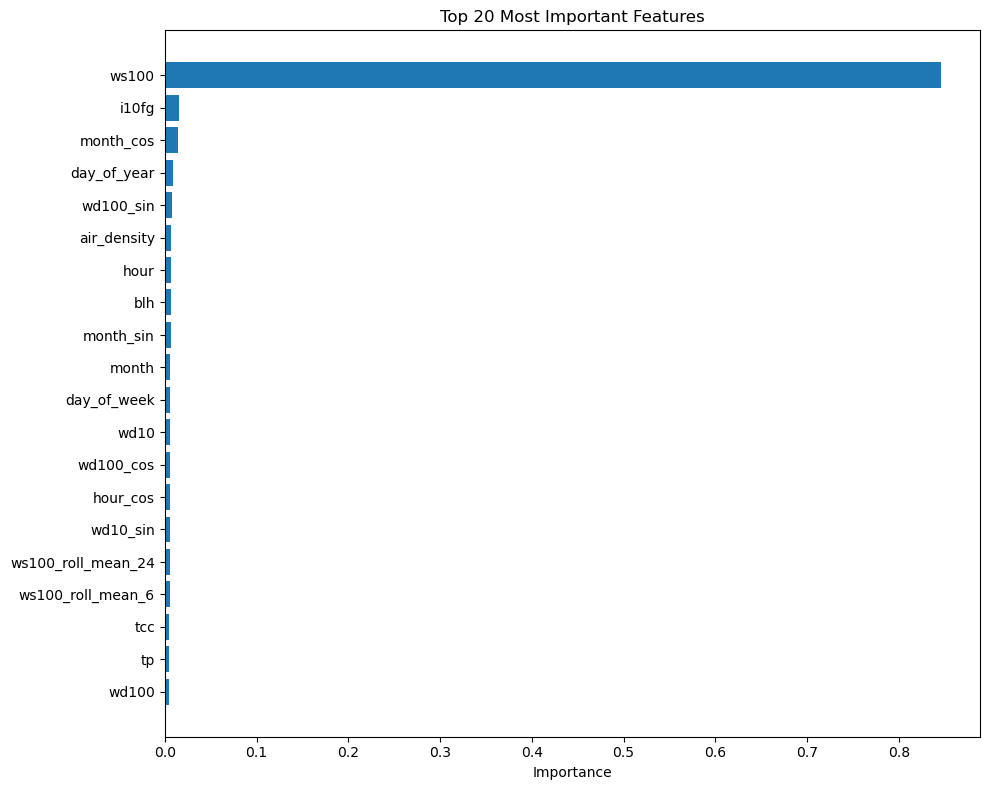

In [146]:
import matplotlib.pyplot as plt

top20 = importance_df.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Most Important Features")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

In [147]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

In [148]:
param_dist = {
    "n_estimators": [100, 300, 500, 700],
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

n_estimator = number of trees, 100 baseline, 300 moderate, 500 commonly used and 700 aggressive
max_depth = how deep trees grow simple, moderate and complex
subsample = controls how much training data each trees see
colsample_bytree = controls how many features each tree can use

<h2>tuned model

In [161]:
xgb_tuned = RandomizedSearchCV(
    estimator=XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    ),
    param_distributions=param_dist,
    n_iter=50,                      
    scoring="neg_mean_squared_error",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

xgb_tuned.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=True,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints...
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [4, 6, 8, 10],
                                        'n_estimators': [100, 300, 500, 700],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=1)

In [162]:
y_tuned_pred = xgb_tuned.predict(X_test)

In [163]:
results = pd.DataFrame({
    'Timestamp': gradient_data.loc[y_test.index, 'timestamp'],
    "Actual": y_test,
    "Predicted": y_tuned_pred
})

results["Error"] = results["Actual"] - results["Predicted"]
results["Absolute_Error"] = results["Error"].abs()

xg_tuned_results = results.copy()

In [164]:
xg_tuned_results

,Timestamp,Actual,Predicted,Error,Absolute_Error
59466,2024-10-20 18:00:00,13901.5,11907.210938,1994.289062,1994.289062
59467,2024-10-20 19:00:00,14090.0,11857.208008,2232.791992,2232.791992
59468,2024-10-20 20:00:00,14069.5,11748.444336,2321.055664,2321.055664
59469,2024-10-20 21:00:00,14113.5,11362.680664,2750.819336,2750.819336
59470,2024-10-20 22:00:00,13417.5,11135.165039,2282.334961,2282.334961
...,...,...,...,...,...
69955,2025-12-31 19:00:00,14324.0,11259.319336,3064.680664,3064.680664
69956,2025-12-31 20:00:00,13765.0,11350.619141,2414.380859,2414.380859
69957,2025-12-31 21:00:00,13578.5,11702.370117,1876.129883,1876.129883
69958,2025-12-31 22:00:00,13776.0,11862.640625,1913.359375,1913.359375


In [165]:
xg_tuned_results.to_csv(
    "../data/results/xgb_tuned_50/xg_tuned_results_50.csv",
    index=False
)

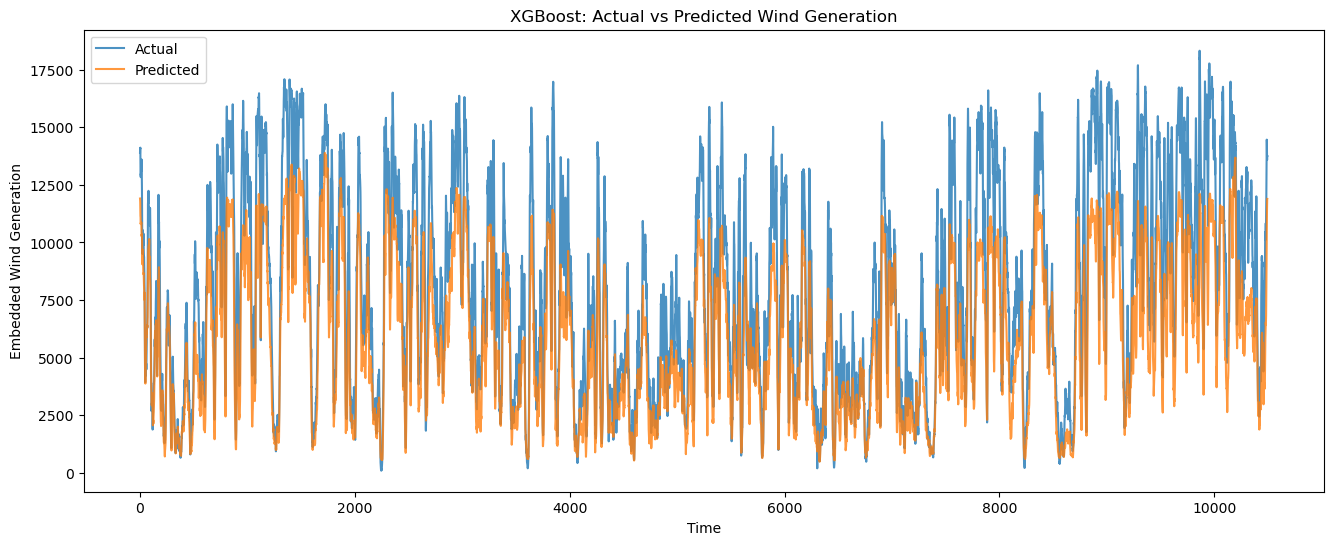

In [166]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))

plt.plot(
    y_test.values,
    label="Actual",
    alpha=0.8
)

plt.plot(
    y_tuned_pred,
    label="Predicted",
    alpha=0.8
)

plt.title("XGBoost: Actual vs Predicted Wind Generation")
plt.xlabel("Time")
plt.ylabel("Embedded Wind Generation")
plt.legend()
plt.show()

In [167]:
best_xgb = xgb_tuned.best_estimator_

y_val_pred_tuned = best_xgb.predict(X_val)

In [168]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_val, y_val_pred_tuned)

mse = mean_squared_error(y_val, y_val_pred_tuned)
rmse= np.sqrt(mse)

r2 = r2_score(y_val, y_val_pred_tuned)

print(f"MAE: {mae: .4f}")
print(f"RMSE: {rmse: .4f}")
print(f"R2: {r2: .4f}")

MAE:  1481.9755
RMSE:  1876.6595
R2:  0.7977


In [169]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_xgb.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
0,ws100,0.375584
10,i10fg,0.271105
23,ws100_roll_mean_6,0.199509
24,ws100_roll_mean_24,0.040474
22,month_cos,0.011128
3,wind_shear,0.011086
20,hour_cos,0.007068
15,hour,0.006983
18,day_of_year,0.006659
6,blh,0.005752


In [170]:
importance_df.to_csv(
    "../data/results/xgb_tuned_50/xg_tuned_vif_50.csv",
    index=False
)

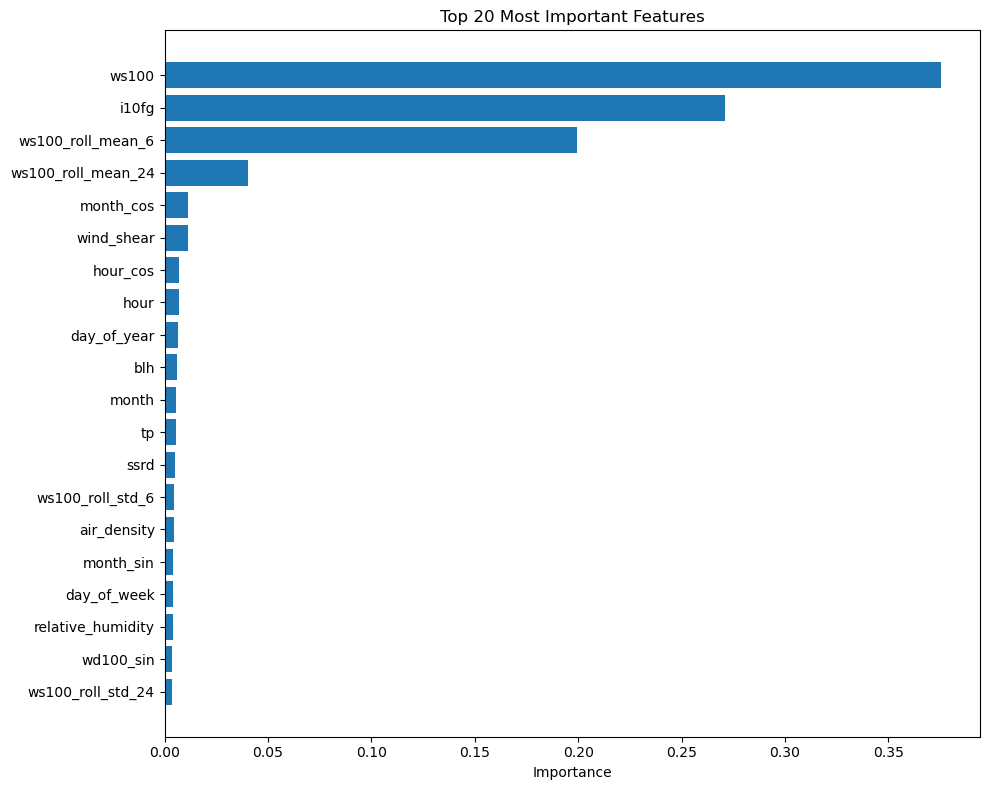

In [171]:
import matplotlib.pyplot as plt

top20 = importance_df.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Most Important Features")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

In [ ]:
#import shap

#explainer = shap.TreeExplainer(xgb)

#shap_values = explainer.shap_values(X_test)

#shap.summary_plot(
#    shap_values,
#    X_test
#)

<h1> xgboost with lag

basic

In [277]:
print(X.columns)

Index(['ws100', 'wd100', 'wd10', 'wind_shear', 'relative_humidity',
       'air_density', 'blh', 'tcc', 'tp', 'ssrd', 'i10fg', 'wd100_sin',
       'wd100_cos', 'wd10_sin', 'wd10_cos', 'hour', 'day_of_week', 'month',
       'day_of_year', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
       'gen_lag_24', 'gen_lag_168', 'ws100_roll_mean_6', 'ws100_roll_mean_24',
       'ws100_roll_std_6', 'ws100_roll_std_24', 'gen_lag_24_roll_mean_6',
       'gen_lag_24_roll_mean_24', 'gen_lag_24_roll_std_6',
       'gen_lag_24_roll_std_24'],
      dtype='object')


In [278]:
from xgboost import XGBRegressor

xgb_l = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb_l.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [201]:
y_pred = xgb_l.predict(X_test)

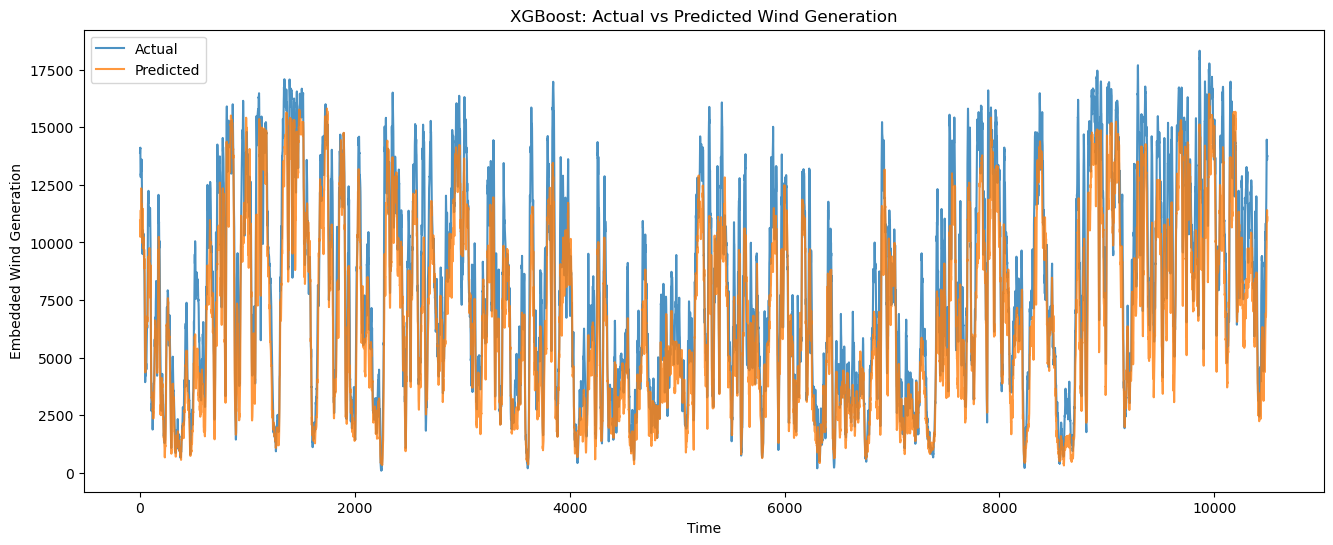

In [202]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))

plt.plot(
    y_test.values,
    label="Actual",
    alpha=0.8
)

plt.plot(
    y_pred,
    label="Predicted",
    alpha=0.8
)

plt.title("XGBoost: Actual vs Predicted Wind Generation")
plt.xlabel("Time")
plt.ylabel("Embedded Wind Generation")
plt.legend()
plt.show()

In [280]:
results = pd.DataFrame({
    'Timestamp': gradient_data.loc[y_test.index, 'timestamp'],
    "Actual": y_test,
    "Predicted": y_pred
})

results["Error"] = results["Actual"] - results["Predicted"]
results["Absolute_Error"] = results["Error"].abs()

xgl_results = results.copy()

In [204]:
xgl_results.to_csv(
    "../data/results/xgb_lag/xgl_results.csv",
    index=False
)

In [205]:
xgl_results

,Timestamp,Actual,Predicted,Error,Absolute_Error
59466,2024-10-20 18:00:00,13901.5,10945.891602,2955.608398,2955.608398
59467,2024-10-20 19:00:00,14090.0,10521.775391,3568.224609,3568.224609
59468,2024-10-20 20:00:00,14069.5,10358.345703,3711.154297,3711.154297
59469,2024-10-20 21:00:00,14113.5,10243.118164,3870.381836,3870.381836
59470,2024-10-20 22:00:00,13417.5,10818.970703,2598.529297,2598.529297
...,...,...,...,...,...
69955,2025-12-31 19:00:00,14324.0,11134.347656,3189.652344,3189.652344
69956,2025-12-31 20:00:00,13765.0,11204.795898,2560.204102,2560.204102
69957,2025-12-31 21:00:00,13578.5,11402.839844,2175.660156,2175.660156
69958,2025-12-31 22:00:00,13776.0,10914.570312,2861.429688,2861.429688


In [206]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y_val_pred = xgb_l.predict(X_val)

mae = mean_absolute_error(y_val, y_val_pred)

mse = mean_squared_error(y_val, y_val_pred)
rmse= np.sqrt(mse)

r2 = r2_score(y_val, y_val_pred)

print(f"MAE: {mae: .4f}")
print(f"RMSE: {rmse: .4f}")
print(f"R2: {r2: .4f}")

MAE:  1172.1494
RMSE:  1547.4083
R2:  0.8625


In [208]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_l.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
0,ws100,0.784166
10,i10fg,0.045260
23,gen_lag_24,0.021779
30,gen_lag_24_roll_mean_24,0.014198
24,gen_lag_168,0.010316
32,gen_lag_24_roll_std_24,0.009217
29,gen_lag_24_roll_mean_6,0.008695
31,gen_lag_24_roll_std_6,0.007803
28,ws100_roll_std_24,0.006544
15,hour,0.006373


In [186]:
importance_df.to_csv(
    "../data/results/xgb_lag/importance.csv",
    index=False
)

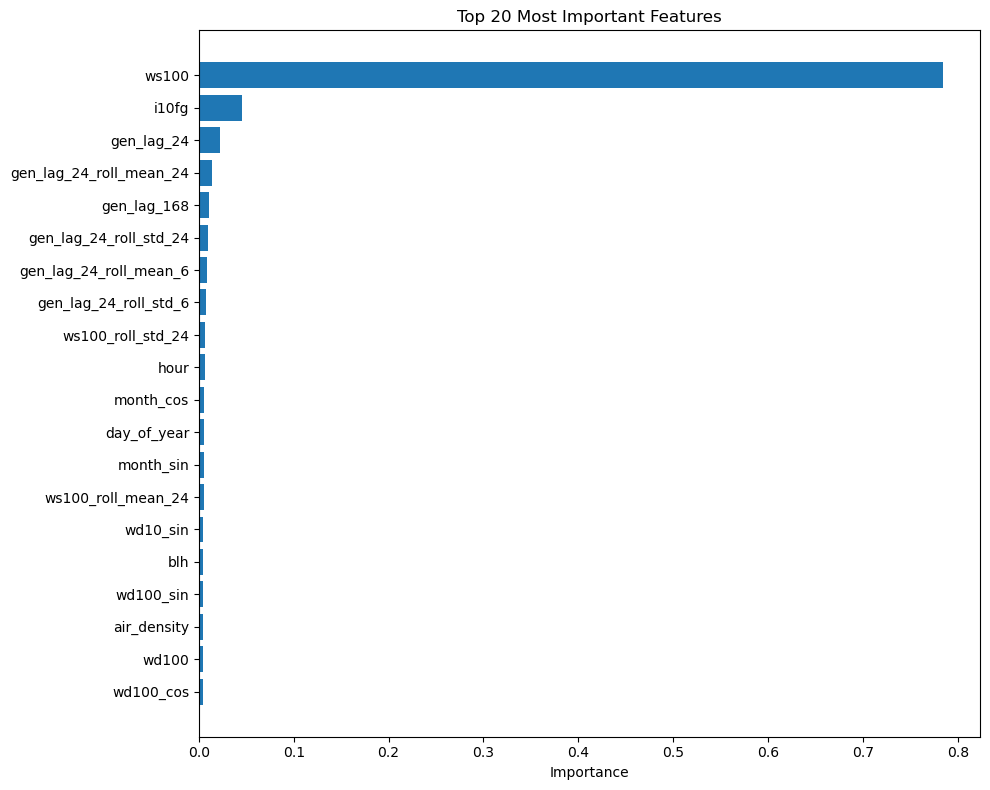

In [209]:
import matplotlib.pyplot as plt

top20 = importance_df.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Most Important Features")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

In [210]:
xgb_l_tuned = RandomizedSearchCV(
    estimator=XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    ),
    param_distributions=param_dist,
    n_iter=20,                      
    scoring="neg_mean_squared_error",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

xgb_l_tuned.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=True,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints...
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [4, 6, 8, 10],
                                        'n_estimators': [100, 300, 500, 700],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=1)

In [211]:
y_tuned_pred = xgb_l_tuned.predict(X_test)

In [212]:
results = pd.DataFrame({
    'Timestamp': gradient_data.loc[y_test.index, 'timestamp'],
    "Actual": y_test,
    "Predicted": y_tuned_pred
})

results["Error"] = results["Actual"] - results["Predicted"]
results["Absolute_Error"] = results["Error"].abs()

xg_l_tuned_results = results.copy()

In [213]:
xg_l_tuned_results

,Timestamp,Actual,Predicted,Error,Absolute_Error
59466,2024-10-20 18:00:00,13901.5,9943.851562,3957.648438,3957.648438
59467,2024-10-20 19:00:00,14090.0,10277.856445,3812.143555,3812.143555
59468,2024-10-20 20:00:00,14069.5,10186.234375,3883.265625,3883.265625
59469,2024-10-20 21:00:00,14113.5,9986.791992,4126.708008,4126.708008
59470,2024-10-20 22:00:00,13417.5,10753.925781,2663.574219,2663.574219
...,...,...,...,...,...
69955,2025-12-31 19:00:00,14324.0,10769.902344,3554.097656,3554.097656
69956,2025-12-31 20:00:00,13765.0,10745.487305,3019.512695,3019.512695
69957,2025-12-31 21:00:00,13578.5,10723.965820,2854.534180,2854.534180
69958,2025-12-31 22:00:00,13776.0,10488.998047,3287.001953,3287.001953


In [214]:
xg_l_tuned_results.to_csv(
    "../data/results/xgb_tuned_lag/xg_l_tuned_results.csv",
    index=False
)

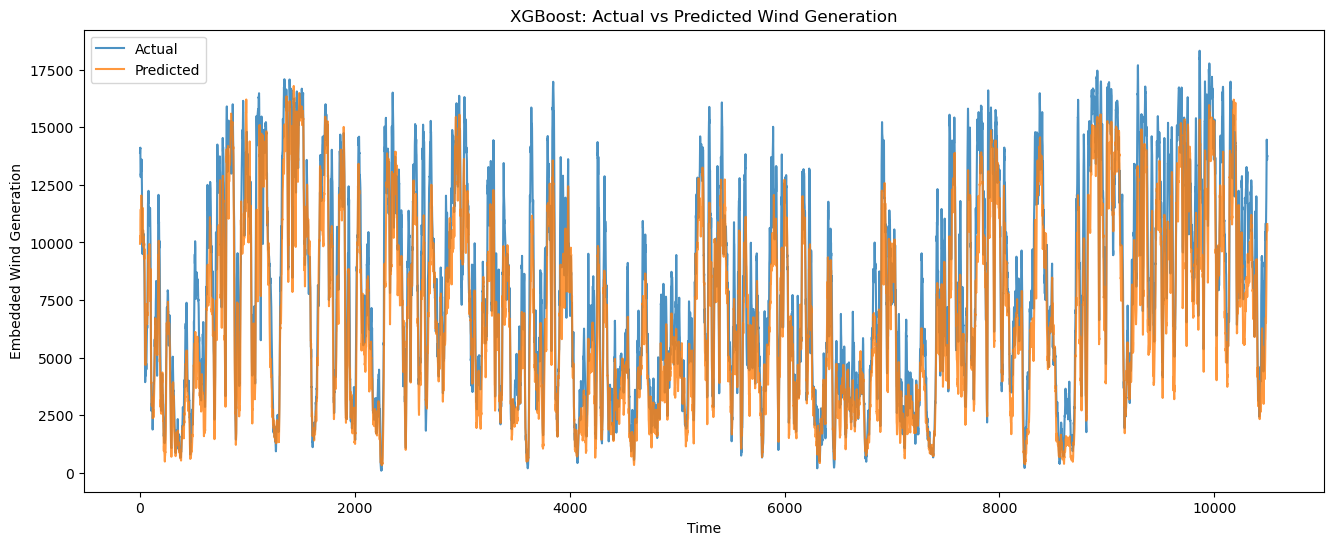

In [215]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))

plt.plot(
    y_test.values,
    label="Actual",
    alpha=0.8
)

plt.plot(
    y_tuned_pred,
    label="Predicted",
    alpha=0.8
)

plt.title("XGBoost: Actual vs Predicted Wind Generation")
plt.xlabel("Time")
plt.ylabel("Embedded Wind Generation")
plt.legend()
plt.show()

In [216]:
xgb_l_t = xgb_l_tuned.best_estimator_

y_val_pred_tuned = xgb_l_t.predict(X_val)


from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_val, y_val_pred_tuned)

mse = mean_squared_error(y_val, y_val_pred_tuned)
rmse= np.sqrt(mse)

r2 = r2_score(y_val, y_val_pred_tuned)

print(f"MAE: {mae: .4f}")
print(f"RMSE: {rmse: .4f}")
print(f"R2: {r2: .4f}")

MAE:  1171.6803
RMSE:  1552.7310
R2:  0.8615


In [217]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_l_t.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
0,ws100,0.391390
25,ws100_roll_mean_6,0.263764
10,i10fg,0.212462
23,gen_lag_24,0.016112
30,gen_lag_24_roll_mean_24,0.012498
24,gen_lag_168,0.010147
31,gen_lag_24_roll_std_6,0.007690
32,gen_lag_24_roll_std_24,0.007041
29,gen_lag_24_roll_mean_6,0.006109
3,wind_shear,0.004972


In [218]:
importance_df.to_csv(
    "../data/results/xgb_tuned_lag/xg_tuned_vif_lag.csv",
    index=False
)

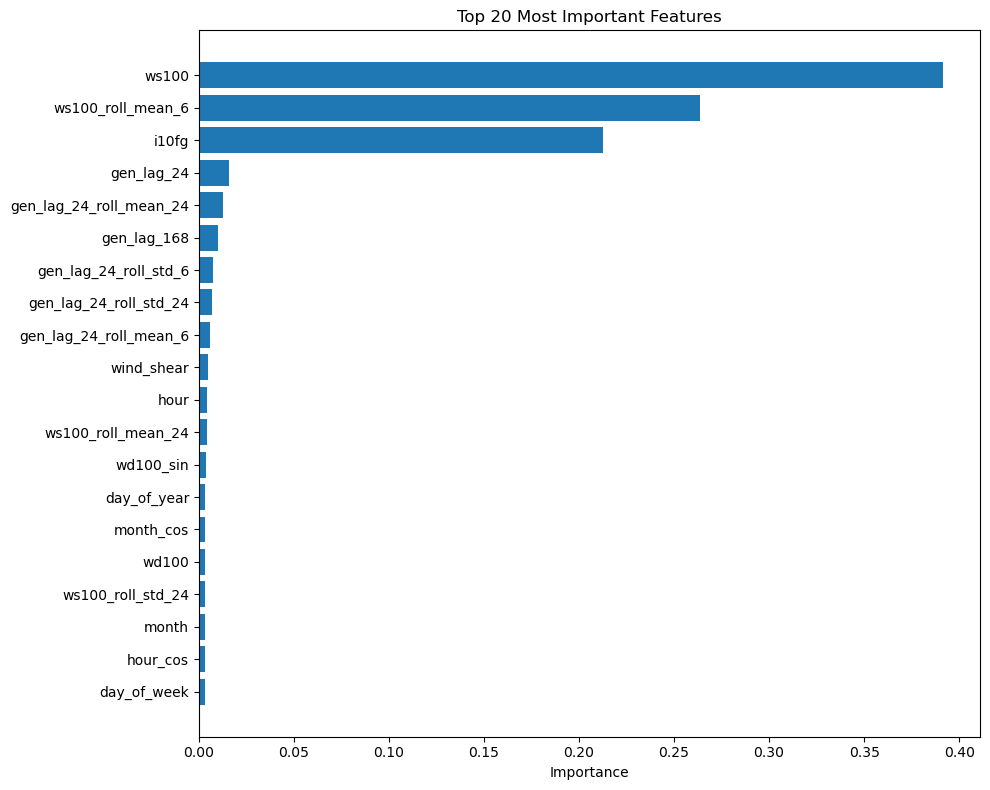

In [219]:
import matplotlib.pyplot as plt

top20 = importance_df.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Most Important Features")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

<h1>lightBGM

In [124]:
#!pip install lightgbm

In [285]:
from lightgbm import LGBMRegressor, early_stopping

lgbm = LGBMRegressor(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

lgbm.fit(X_train, y_train,
         eval_set=[(X_val, y_val)],
         callbacks=[early_stopping(stopping_rounds=50, verbose=True)]) #if learning rate doesnot improve at 50 rounds exit

c:\Users\LOQ\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005234 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6734
[LightGBM] [Info] Number of data points in the train set: 48972, number of used features: 33
[LightGBM] [Info] Start training from score 5847.465419
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[401]	valid_0's l2: 2.38019e+06


LGBMRegressor(learning_rate=0.05, max_depth=6, n_estimators=1000, n_jobs=-1,
              random_state=42)

In [286]:
y_val_pred_lgbm = lgbm.predict(X_val)

In [287]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_val, y_val_pred_lgbm)

mse = mean_squared_error(y_val, y_val_pred_lgbm)
rmse= np.sqrt(mse)

r2 = r2_score(y_val, y_val_pred_lgbm)

print(f"MAE: {mae: .4f}")
print(f"RMSE: {rmse: .4f}")
print(f"R2: {r2: .4f}")

MAE:  1164.8504
RMSE:  1542.7879
R2:  0.8633


In [288]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": lgbm.feature_importances_
})

importance_df.sort_values(
    "Importance",
    ascending=False
).head(60)

,Feature,Importance
18,day_of_year,1256
30,gen_lag_24_roll_mean_24,749
26,ws100_roll_mean_24,720
5,air_density,691
0,ws100,669
24,gen_lag_168,665
23,gen_lag_24,605
28,ws100_roll_std_24,511
32,gen_lag_24_roll_std_24,503
2,wd10,446


In [289]:
importance_df.to_csv(
    "../data/results/lightbgm/vif.csv",
    index=False
)

In [290]:
y_lgbm_pred = lgbm.predict(X_test)

In [291]:
results = pd.DataFrame({
    'Timestamp': gradient_data.loc[y_test.index, 'timestamp'],
    "Actual": y_test,
    "Predicted": y_tuned_pred
})

results["Error"] = results["Actual"] - results["Predicted"]
results["Absolute_Error"] = results["Error"].abs()

xg_l_tuned_results = results.copy()

In [292]:
lgbm_results

,Timestamp,Actual,Predicted,Error,Absolute_Error
59466,2024-10-20 18:00:00,13901.5,11092.160014,2809.339986,2809.339986
59467,2024-10-20 19:00:00,14090.0,10712.933774,3377.066226,3377.066226
59468,2024-10-20 20:00:00,14069.5,10275.667437,3793.832563,3793.832563
59469,2024-10-20 21:00:00,14113.5,10233.590620,3879.909380,3879.909380
59470,2024-10-20 22:00:00,13417.5,10480.269208,2937.230792,2937.230792
...,...,...,...,...,...
69955,2025-12-31 19:00:00,14324.0,11093.193942,3230.806058,3230.806058
69956,2025-12-31 20:00:00,13765.0,10927.357975,2837.642025,2837.642025
69957,2025-12-31 21:00:00,13578.5,11055.039036,2523.460964,2523.460964
69958,2025-12-31 22:00:00,13776.0,10879.926107,2896.073893,2896.073893


In [293]:
lgbm_results.to_csv(
    "../data/results/lightbgm/results.csv",
    index=False
)

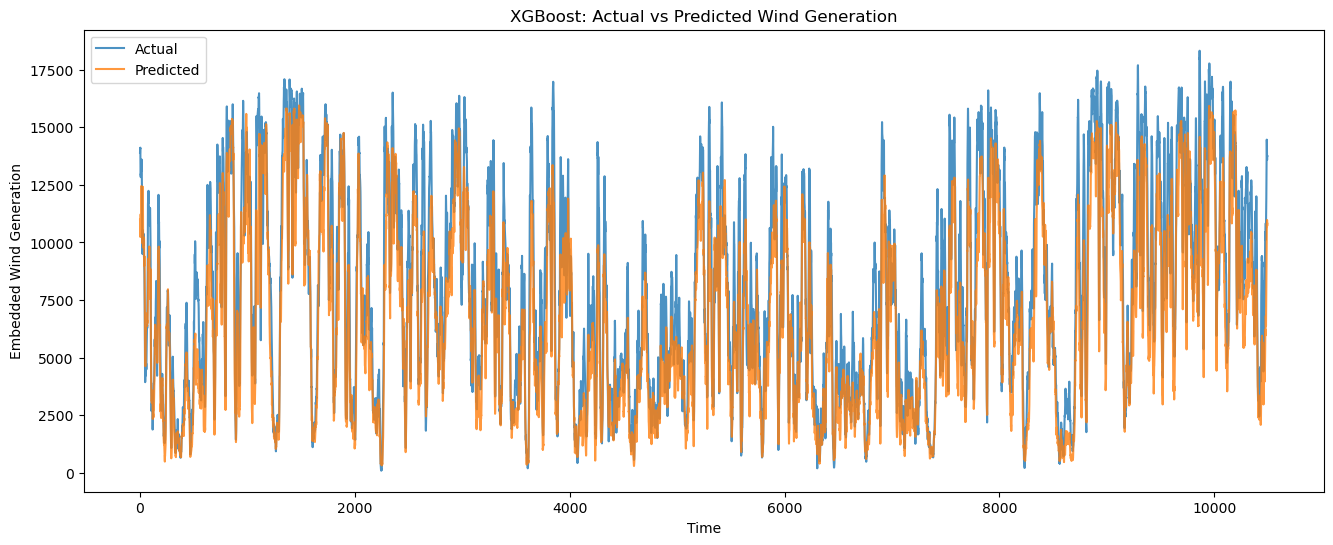

In [294]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))

plt.plot(
    y_test.values,
    label="Actual",
    alpha=0.8
)

plt.plot(
    y_lgbm_pred,
    label="Predicted",
    alpha=0.8
)

plt.title("XGBoost: Actual vs Predicted Wind Generation")
plt.xlabel("Time")
plt.ylabel("Embedded Wind Generation")
plt.legend()
plt.show()

<h2>tuned lightBGM

In [299]:
param_dist = {
    "n_estimators": [100, 300, 500, 100],
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [31, 50, 70, 100],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

In [300]:
lgbm_tuned = RandomizedSearchCV(
    estimator=XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    ),
    param_distributions=param_dist,
    n_iter=20,                      
    scoring="neg_mean_squared_error",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

lgbm_tuned.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


c:\Users\LOQ\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:48:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "num_leaves" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=True,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [4, 6, 8, 10],
                                        'n_estimators': [100, 300, 500, 100],
                                        'num_leaves': [31, 50, 70, 100],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=1)

In [301]:
y_val_pred_lgbm_tuned = lgbm_tuned.predict(X_val)

In [302]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_val, y_val_pred_lgbm_tuned)

mse = mean_squared_error(y_val, y_val_pred_lgbm_tuned)
rmse= np.sqrt(mse)

r2 = r2_score(y_val, y_val_pred_lgbm_tuned)
print(f"MAE: {mae: .4f}")
print(f"RMSE: {rmse: .4f}")
print(f"R2: {r2: .4f}")

MAE:  1170.5158
RMSE:  1548.5463
R2:  0.8623


<h1>LSTM

In [362]:
rnn_data.columns

Index(['ws100', 'wd100', 'wd10', 'wind_shear', 'relative_humidity',
       'air_density', 'blh', 'tcc', 'tp', 'ssrd', 'i10fg', 'WIND', 'wd100_sin',
       'wd100_cos', 'wd10_sin', 'wd10_cos', 'hour', 'day_of_week', 'month',
       'day_of_year', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos'],
      dtype='object')

In [363]:
rnn_data["lag_gen_24"] = rnn_data["WIND"].shift(24)

In [367]:
rnn_data = rnn_data.dropna()

In [368]:
rnn_data.isna().sum()

ws100                0
wd100                0
wd10                 0
wind_shear           0
relative_humidity    0
air_density          0
blh                  0
tcc                  0
tp                   0
ssrd                 0
i10fg                0
WIND                 0
wd100_sin            0
wd100_cos            0
wd10_sin             0
wd10_cos             0
hour                 0
day_of_week          0
month                0
day_of_year          0
hour_sin             0
hour_cos             0
month_sin            0
month_cos            0
lag_gen_24           0
dtype: int64

In [369]:
X = rnn_data.drop(columns=["WIND", "hour", "month", "day_of_year", "day_of_week"])
y = rnn_data["WIND"]

In [370]:
X.columns

Index(['ws100', 'wd100', 'wd10', 'wind_shear', 'relative_humidity',
       'air_density', 'blh', 'tcc', 'tp', 'ssrd', 'i10fg', 'wd100_sin',
       'wd100_cos', 'wd10_sin', 'wd10_cos', 'hour_sin', 'hour_cos',
       'month_sin', 'month_cos', 'lag_gen_24'],
      dtype='object')

In [371]:
train_size = int(len(X) * 0.70)
val_size = int(len(X) * 0.15)

X_train = X.iloc[:train_size]
X_val = X.iloc[train_size:train_size + val_size]
X_test = X.iloc[train_size + val_size:]

y_train = y.iloc[:train_size]
y_val = y.iloc[train_size:train_size + val_size]
y_test = y.iloc[train_size + val_size:]

In [374]:
from sklearn.preprocessing import MinMaxScaler

feature_scaler = MinMaxScaler()

X_train_scaled = feature_scaler.fit_transform(X_train)

X_val_scaled = feature_scaler.transform(X_val)

X_test_scaled = feature_scaler.transform(X_test)

In [375]:
target_scaler = MinMaxScaler()

y_train_scaled = target_scaler.fit_transform(
    y_train.values.reshape(-1,1)
)

y_val_scaled = target_scaler.transform(
    y_val.values.reshape(-1,1)
)

y_test_scaled = target_scaler.transform(
    y_test.values.reshape(-1,1)
)

In [376]:
lookback = 24

import numpy as np

def create_sequences(X, y, lookback):

    X_seq = []
    y_seq = []

    for i in range(lookback, len(X)):
        X_seq.append(X[i-lookback:i])
        y_seq.append(y[i])

    return (
        np.array(X_seq),
        np.array(y_seq)
    )

In [377]:
X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train_scaled,
    lookback
)

X_val_seq, y_val_seq = create_sequences(
    X_val_scaled,
    y_val_scaled,
    lookback
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    y_test_scaled,
    lookback
)

In [378]:
print(X_train_seq.shape)
print(y_train_seq.shape)

(49048, 24, 20)
(49048, 1)


In [46]:
!pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 2.4/351.2 MB 11.7 MB/s eta 0:00:30
    --------------------------------------- 4.7/351.2 MB 11.7 MB/s eta 0:00:30
    --------------------------------------- 7.1/351.2 MB 11.6 MB/s eta 0:00:30
   - -------------------------------------- 9.4/351.2 MB 11.6 MB/s eta 0:00:30
   - -------------------------------------- 11.8/351.2 MB 11.6 MB/s eta 0:00:30
   - -------------------------------------- 14.4/351.2 MB 11.6 MB/s eta 0:00:30
   - -------------------------------------- 16.5/351.2 MB 11.6 MB/s eta 0:00:29
   -- ------------------------------------- 18.9/351.2 MB 11.6 MB/s eta 0:00:29
   -- ------------------------------------- 21.2/351.2 MB 11.5 MB/s eta 0:00:29
   -- ------------------------------------- 23.6/351.2 MB 11.5 MB/s eta 0:00:29
   -- ------------------------------------- 25.7/351.2 MB 11.4 MB/s eta 0:00:29
   --- ------------------------------------ 28.0/351.

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.35.1 which is incompatible.


In [383]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [394]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [395]:
lstm_model = Sequential()

lstm_model.add(
    LSTM(
        32,
        input_shape=(
            X_train_seq.shape[1],
            X_train_seq.shape[2]
        ),
        dropout=0.3,
        recurrent_dropout=0.3
    )
)

lstm_model.add(Dropout(0.3))

lstm_model.add(Dense(1))

c:\Users\LOQ\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [396]:
lstm_model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='mse'
)

In [388]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tensorflow.keras.callbacks import Callback


In [389]:
class VSCodeLivePlot(Callback):
    def on_train_begin(self, logs={}):
        self.losses = []
        self.val_losses = []
        # Create a persistent fig and axis to prevent flickering in VS Code
        self.fig, self.ax = plt.subplots(figsize=(9, 4.5))
        
    def on_epoch_end(self, epoch, logs={}):
        self.losses.append(logs.get('loss'))
        self.val_losses.append(logs.get('val_loss'))
        
        # Clear the old lines from the axis, not the whole window
        self.ax.clear()
        
        # Redraw the updated lines
        self.ax.plot(self.losses, label='Training Loss', color='#1f77b4', linewidth=2)
        self.ax.plot(self.val_losses, label='Validation Loss', color='#ff7f0e', linewidth=2)
        
        # Format the graph
        self.ax.set_title(f'LSTM Live Monitor - Epoch {epoch + 1}', fontsize=12, fontweight='bold')
        self.ax.set_xlabel('Epochs')
        self.ax.set_ylabel('Loss (MSE)')
        self.ax.grid(True, linestyle='--', alpha=0.5)
        self.ax.legend(loc='upper right')
        
        # Force VS Code to refresh the specific active cell output region
        clear_output(wait=True)
        display(self.fig)
        
    def on_train_end(self, logs={}):
        # Close the persistent figure when finished so it doesn't duplicate
        plt.close(self.fig)


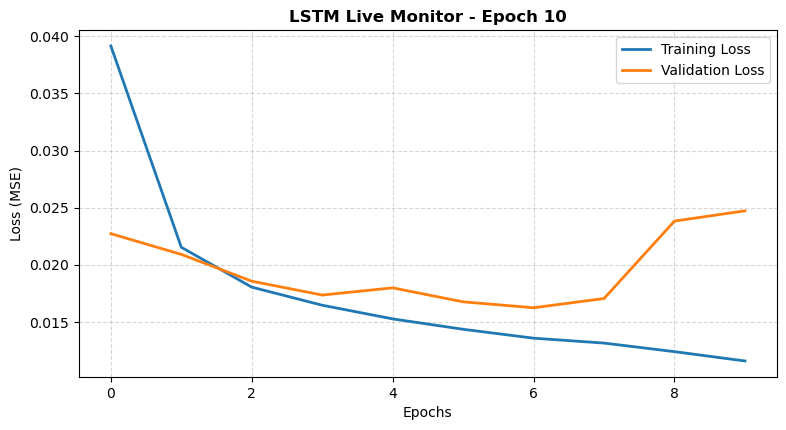

In [397]:
live_plot = VSCodeLivePlot()

history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(
        X_val_seq,
        y_val_seq
    ),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop, live_plot],
    verbose=0
)

In [398]:
y_val_pred_scaled = lstm_model.predict(
    X_val_seq
)

328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


In [399]:
y_val_pred = target_scaler.inverse_transform(
    y_val_pred_scaled
)

y_val_actual = target_scaler.inverse_transform(
    y_val_seq
)

In [400]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(
    y_val_actual,
    y_val_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_val_actual,
        y_val_pred
    )
)

r2 = r2_score(
    y_val_actual,
    y_val_pred
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 1729.0313355207056
RMSE: 2208.4982729442313
R2: 0.7201829195768876


<h1>BiLSTM

In [401]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

bilstm_model = Sequential()

bilstm_model.add(
    Bidirectional(
        LSTM(32),
        input_shape=(
            X_train_seq.shape[1],
            X_train_seq.shape[2]
        )
    )
)

bilstm_model.add(Dropout(0.2))

bilstm_model.add(Dense(1))

bilstm_model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='mse'
)

c:\Users\LOQ\anaconda3\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:110: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


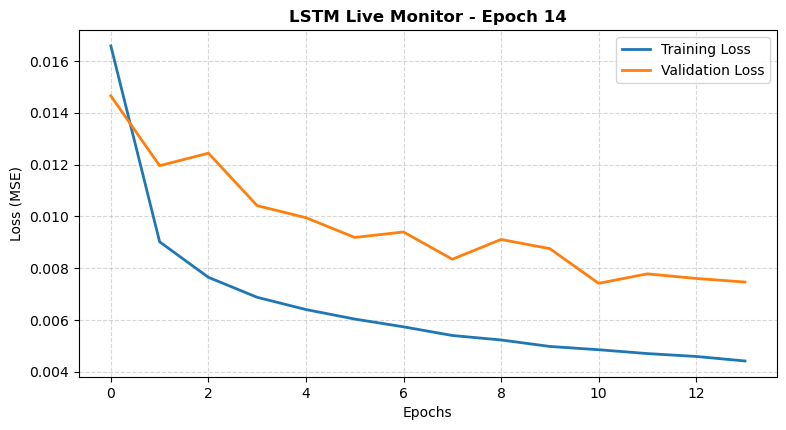

In [402]:
history = bilstm_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop, live_plot],
    verbose=0
)

In [403]:
y_val_pred_scaled = bilstm_model.predict(X_val_seq)

y_val_pred = target_scaler.inverse_transform(
    y_val_pred_scaled
)

y_val_actual = target_scaler.inverse_transform(
    y_val_seq
)

328/328 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [404]:
mae = mean_absolute_error(
    y_val_actual,
    y_val_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_val_actual,
        y_val_pred
    )
)

r2 = r2_score(
    y_val_actual,
    y_val_pred
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 1141.6941309163335
RMSE: 1491.9132101394432
R2: 0.8723069642836088


In [405]:
%reset